Avances 19/feb/2026


En este documento que esta conectado al resto de mi tesis, voy a realizar una síntesis del concepto de probabilidad de éxito del algoritmo y a definir algunos conceptos que nos pueden ser de utilidad para la realización del paper. Se abordara solo un pequeño nivel de las Fuzzy Measurments de las cuales existen. Para eso, definiré cada concepto de manera independiente y asumiremos comodidad completa con el algoritmo de Shor

Tal y como está redactado en mi Diccionario de conceptos de tesis, en el cual sintetizo todos los conceptos necesarios para la comprensión de la tesis, defino los siguientes conceptos

## Medición Difusa

Una medición difusa es un proceso de medición cuántica en el que existe
incertidumbre respecto a qué qubit o subsistema fue realmente observado.
Este fenómeno se modela mediante un canal completamente positivo y
trazapreservante de la forma


$F[\rho] = \sum_{P \in S} p_P\, P \rho P^\dagger,$

donde $\rho$ es el estado inicial del sistema, $S$ es un conjunto de
permutaciones que representan confusión entre qubits, cada $P\in S$ es un
operador de permutación (por ejemplo, una compuerta SWAP) y los coeficientes
$\{p_P\}$ constituyen una distribución de probabilidad.

### Probabilidad de error de la medición difusa

La probabilidad de error de una medición difusa es el valor $p$ que
aparece en la definición del canal cuántico


$F[\rho] = p\, P\rho P^\dagger + (1-p)\rho,$

y representa la probabilidad de que el sistema experimente la permutación
$P$ asociada a la confusión del detector, frente a la probabilidad $1-p$ de
que el estado permanezca sin alteración.

En general, distintos tipos de mediciones difusas pueden involucrar múltiples
operadores de permutación, cada uno con su propio valor de probabilidad.
No obstante, dado que en este reporte únicamente se considera un tipo de
medición difusa basado en la aplicación de una sola permutación $P$, la probabilidad de error
de la medición difusa se define como el valor único $p$ asociado a dicha
permutación.

### Tipos de medición difusa a estudiar:

#### Entre 2 qubits

Una medición difusa entre 2 qubits es un tipo particular de medición
difusa en el que la incertidumbre del detector se modela mediante una única
compuerta SWAP aplicada entre dos qubits arbitrarios del sistema. Esta
permutación representa la posibilidad de que el detector confunda cuál de los
dos qubits produjo el resultado.

El canal cuántico correspondiente está dado por

$F[\rho] = p\, \mathrm{SWAP}_{i,j}\, \rho\, \mathrm{SWAP}_{i,j}^\dagger + (1-p)\rho,$

donde $\rho$ es el estado cuántico previo, $\mathrm{SWAP}_{i,j}$ es la
compuerta que intercambia los qubits $i$ y $j$, y $p$ es la probabilidad de
error asociada a esta medición difusa.

#### Circular

Una \emph{medición difusa circular} es un tipo de medición difusa cuyo error se
modela mediante una permutación circular del registro. Dicha permutación rota
las posiciones del sistema un número $k$ de lugares, donde $1 \le k \le l-1$,
enviando cada qubit a una posición desplazada cíclicamente.

Para una rotación de $k$ posiciones, la permutación circular satisface

$P_{\mathrm{circ},k}(i) = i+k \pmod{l},$

de modo que casos particulares incluyen rotaciones de $1$, $2$, \ldots,
$k$ lugares.

El canal cuántico correspondiente se define como


$F[\rho] = p\, P_{\mathrm{circ},k}\, \rho\, P_{\mathrm{circ},k}^\dagger + (1-p)\rho,$

donde $P_{\mathrm{circ},k}$ es la permutación circular de $k$ posiciones, $p$ es
la probabilidad de error y $\rho$ es el estado cuántico previo.


#### De todas las parejas adyacentes


Una medición difusa entre todas las parejas adyacentes es un tipo de
medición difusa en la que la confusión se modela mediante una permutación que
intercambia simultáneamente cada par de qubits adyacentes del registro, es
decir, las parejas $(1,2)$, $(3,4)$, $(5,6)$, \ldots.

El canal cuántico correspondiente se define como

$F[\rho] = p\, P_{\mathrm{adj}}\, \rho\, P_{\mathrm{adj}}^\dagger + (1-p)\rho,$

donde $P_{\mathrm{adj}}$ es la permutación compuesta por todos los SWAP
adyacentes, $p$ es la probabilidad de error y $\rho$ es el estado cuántico previo.


Con la teoría necesaria de mediciones difusas, pasemos ahora a explicar la teoría relacionada con las probabilidades de éxito del algoritmo de Shor pre y post mediciones difusas:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from fractions import Fraction




def graficar_probabilidades(probs, 
                            titulo="Amplitudes de probabilidad", 
                            tipo_etiqueta="bin", 
                            etiquetas_personalizadas=None,
                            rango=None,
                            ys_exitosos=None):

    probs = np.array(probs, dtype=float)
    if not np.isclose(np.sum(probs), 1):
        probs = probs / np.sum(probs)

    n_total = len(probs)
    x_total = np.arange(n_total)

    # --- Generación de etiquetas 
    if tipo_etiqueta == "num":
        etiquetas_total = [str(i) for i in range(n_total)]

    elif tipo_etiqueta == "bin":
        k = max(1, math.ceil(math.log2(n_total)))
        etiquetas_total = [format(i, f"0{k}b") for i in range(n_total)]

    else:
        raise ValueError("tipo_etiqueta debe ser 'num' o 'bin'")

    # --- Aplicar rango ---
    if rango is not None:
        inicio, fin = rango
        if not (0 <= inicio < fin <= n_total):
            raise ValueError(f"Rango inválido: debe estar dentro de [0, {n_total})")
        probs = probs[inicio:fin]
        x = np.arange(inicio, fin)
        etiquetas = etiquetas_total[inicio:fin]
    else:
        x = x_total
        etiquetas = etiquetas_total

    n = len(probs)

    # --- Colores personalizados si ys_exitosos está definido ---
    if ys_exitosos is not None:
        colors = ["red" if i in ys_exitosos else "steelblue" for i in x]
    else:
        colors = "steelblue"

    # --- Ajustes automáticos ---
    ancho_figura = max(8, n * 0.25)
    rotacion_etiquetas = 90 if n > 16 else 45 if n > 8 else 0
    if n > 512:
        fontsize_etiquetas = 8
    elif n > 128:
        fontsize_etiquetas = 10
    elif n > 32:
        fontsize_etiquetas = 12
    else:
        fontsize_etiquetas = 14

    # --- Graficar ---
    plt.figure(figsize=(ancho_figura, 5))
    plt.bar(x, probs, width=0.8, color=colors)
    plt.xticks(x, etiquetas, rotation=rotacion_etiquetas, fontsize=fontsize_etiquetas)
    plt.ylabel("Probabilidad", fontsize=14)
    plt.title(titulo, fontsize=16)
    plt.ylim(0, max(probs) * 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def probs_teoricas_QPE_l(r, l):
    Q = 2**l  # tamaño del registro ancilla
    q = Q // r
    c = Q % r
    Q0 = r * q
    
    probs = np.zeros(Q, dtype=float)
    
    for y in range(Q):
        if (r * y) % Q != 0:  # caso general
            num = (
                c * np.sin(np.pi * r * y / Q * (Q0 / r + 1))**2
                + (r - c) * np.sin(np.pi * r * y / Q * (Q0 / r))**2
            )
            den = (Q**2) * (np.sin(np.pi * r * y / Q)**2)
            probs[y] = num / den if den != 0 else 0.0
        else:  # caso múltiplo exacto
            probs[y] = (
                c * (Q0 + r)**2 + (r - c) * (Q0**2)
            ) / (Q**2 * r**2)
    
    return probs

In [ ]:
def U_swap(n, a, b):

    if not (0 <= a < n) or not (0 <= b < n):
        raise ValueError("Los índices de qubits deben cumplir 0 <= a,b < n.")
    if a == b:
        raise ValueError("a y b deben ser qubits distintos.")

    dim = 1 << n  # 2**n
    U = np.zeros((dim, dim), dtype=complex)

    # Convertimos de índice físico a posición en el entero (LSB indexing)
    j1 = n - 1 - a
    j2 = n - 1 - b

    for i in range(dim):
        # extraer bit j1 y j2
        b1 = (i >> j1) & 1
        b2 = (i >> j2) & 1

        if b1 == b2:
            j = i  # no cambia nada si los bits son iguales
        else:
            # flip de ambos bits
            j = i ^ (1 << j1) ^ (1 << j2)

        U[j, i] = 1.0

    return U



def U_swap_circular(l):
    U = np.eye(2**l, dtype=complex)
    for k in range(l-1):
        U = U_swap(l, k, k+1) @ U
    return U


def U_swap_circular_k(l, k):
    k = k % l  # rotaciones equivalentes mod l
    U = np.eye(2**l, dtype=complex)
    if k == 0:
        return U
    U1 = U_swap_circular(l)
    for _ in range(k):
        U = U1 @ U
    return U


def U_swap_all_pairs(n):
    """
    Aplica SWAP en todas las parejas de qubits adyacentes:
    (0<->1), (2<->3), (4<->5), ...
    """
    if n % 2 != 0:
        raise ValueError("Para intercambiar todas las parejas, n debe ser par.")
    
    U = np.eye(2**n, dtype=complex)
    for k in range(0, n, 2):
        U = U_swap_adjacent(n, k) @ U
    return U

def U_swap_adjacent(n, k):
    if not (0 <= k < n-1):
        raise ValueError("k debe cumplir 0 <= k < n-1.")

    dim = 1 << n  # 2**n
    U = np.zeros((dim, dim), dtype=complex)

    # En esta convención, el bit físico k (MSB indexing) está en posición LSB j1 = n-1-k.
    j1 = n - 1 - k
    j2 = n - 1 - (k + 1)

    for i in range(dim):
        # extrae bits
        b1 = (i >> j1) & 1
        b2 = (i >> j2) & 1
        if b1 == b2:
            j = i
        else:
            # flip de ambos bits
            j = i ^ (1 << j1) ^ (1 << j2)
        U[j, i] = 1.0
    # return U

def y_que_recuperan_r(r_real, l):
    Q = 2**l
    ys_exitosos = []

    for y in range(Q):
        x = y / Q
        convergentes = fracciones_continuas(x, M=Q)

        for (p, q) in convergentes:
            if q != 0:
                approx = Fraction(p, q).limit_denominator()
                if approx.denominator == r_real:
                    ys_exitosos.append(y)
                    break  

    return ys_exitosos

def fracciones_continuas(x, M):
    convergentes = []
    a0 = int(np.floor(x))
    p_menos2, q_menos2 = 0, 1
    p_menos1, q_menos1 = 1, 0
    
    xi = x
    k = 0
    while True:
        ak = int(np.floor(xi))
        pk = ak * p_menos1 + p_menos2
        qk = ak * q_menos1 + q_menos2
        
        convergentes.append((pk, qk))
        
        if qk > M or abs(xi - ak) < 1e-12:
            break
        
        p_menos2, q_menos2 = p_menos1, q_menos1
        p_menos1, q_menos1 = pk, qk
        xi = 1/(xi - ak)
        k += 1
    
    return convergentes


Funciones para correr el algoritmo de Order Finding desde 0:

In [28]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector, partial_trace
import numpy as np
from math import pi, gcd

def U_mod(a, N, n):
    """Construye la matriz unitaria modular U|y> = |a*y mod N>."""
    dim = 2**n
    if dim < N:
        raise ValueError("2**n debe ser >= N")
    if gcd(a, N) != 1:
        raise ValueError("a y N deben ser coprimos")

    U = np.zeros((dim, dim), dtype=complex)
    for y in range(N):
        U[(a * y) % N, y] = 1.0
    for y in range(N, dim):
        U[y, y] = 1.0
    return U


def QPE_qiskit(l, n, a, N):
    """
    Simula el algoritmo de Quantum Phase Estimation (QPE)
    con QFT inversa manual, usando una unitaria modular U_mod(a, N, n).

    Parámetros:
        l (int): número de qubits en el registro ancilla
        n (int): número de qubits en el registro principal
        a (int): base modular (coprima con N)
        N (int): módulo usado en U_mod

    Devuelve:
        rho_ancilla (np.ndarray): matriz densidad del registro ancilla
    """

    # ------------------------------------------------------------
    # 1. Registros cuánticos
    # ------------------------------------------------------------
    ancilla = QuantumRegister(l, "ancilla")
    principal = QuantumRegister(n, "principal")
    c_ancilla = ClassicalRegister(l, "c_ancilla")
    qc = QuantumCircuit(ancilla, principal, c_ancilla)

    # ------------------------------------------------------------
    # 2. Inicialización
    # ------------------------------------------------------------
    qc.h(ancilla)             # superposición uniforme en ancilla
    qc.x(principal[0])        # inicializa |1> en el registro principal
    qc.barrier()

    # ------------------------------------------------------------
    # 3. Construcción de la unitaria U(a, N, n)
    # ------------------------------------------------------------
    U = U_mod(a, N, n)
    assert np.allclose(U.conj().T @ U, np.eye(U.shape[0])), "La matriz U no es unitaria"

    # Cadena de controlled-U^(2^j)
    for j in range(l):
        U_power = np.linalg.matrix_power(U, 2**j)
        CU_gate = UnitaryGate(U_power, label=f"U^{2**j}").control(1)
        qc.append(CU_gate, [ancilla[j]] + list(principal))

    qc.barrier()

    # ------------------------------------------------------------
    # 4. QFT inversa manual
    # ------------------------------------------------------------
    # Paso 1: swap del orden de qubits
    for i in range(l // 2):
        qc.swap(ancilla[i], ancilla[l - i - 1])

    # Paso 2: rotaciones controladas + Hadamards
    for j in range(l):
        for k in range(j):
            qc.cp(-pi / (2 ** (j - k)), ancilla[k], ancilla[j])
        qc.h(ancilla[j])

    qc.barrier()

    # ------------------------------------------------------------
    # 5. Guardar matriz densidad del registro ancilla
    # ------------------------------------------------------------
    qc.save_density_matrix(qubits=ancilla)

    # (Opcional) medir el registro ancilla
    qc.measure(ancilla, c_ancilla)

    # ------------------------------------------------------------
    # 6. Simulación
    # ------------------------------------------------------------
    simulator = AerSimulator()
    qc_t = transpile(qc, simulator)
    job = simulator.run(qc_t)
    result = job.result()

    rho_ancilla = result.data()['density_matrix']
    return rho_ancilla


def probabilidad_exito_QPE(r, l):
    """
    Devuelve la probabilidad total de éxito del algoritmo QPE
    para periodo r y registro de l qubits.
    """

    probs = probs_teoricas_QPE_l(r, l)
    ys_exitosos = y_que_recuperan_r(r, l)

    prob_exito = sum(probs[y] for y in ys_exitosos)

    return prob_exito



In [24]:
def graficar_pendientes_swaps_circulares(r, l, n_puntos=30):

    ps = np.linspace(0, 1, n_puntos)

    probs = probs_teoricas_QPE_l(r, l)
    ys_exitosos = y_que_recuperan_r(r, l)

    pendientes = []

    for k in range(1, l):

        prob_exito_vs_p = []
        U = U_swap_circular_k(l, k)

        for p in ps:
            errprobs = (1 - p) * probs + p * (U @ probs)
            prob_exito = sum(errprobs[y] for y in ys_exitosos)
            prob_exito_vs_p.append(prob_exito)

        pendiente, _ = np.polyfit(ps, prob_exito_vs_p, 1)
        pendientes.append(pendiente)

    ks = np.arange(1, l)

    plt.figure(figsize=(8,5))
    plt.bar(ks, pendientes)
    plt.xlabel("Rotación circular k")
    plt.ylabel("Pendiente")
    plt.title(f"Pendientes SWAP circular (r={r}, l={l})")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def graficar_pendientes_swap_fijo(r, l, qubit_fijo, n_puntos=30):

    ps = np.linspace(0, 1, n_puntos)

    probs = probs_teoricas_QPE_l(r, l)
    ys_exitosos = y_que_recuperan_r(r, l)

    pendientes = []
    qubits = []

    for j in range(l):

        if j == qubit_fijo:
            continue

        prob_exito_vs_p = []
        U = U_swap(l, qubit_fijo, j)

        for p in ps:
            errprobs = (1 - p) * probs + p * (U @ probs)
            prob_exito = sum(errprobs[y] for y in ys_exitosos)
            prob_exito_vs_p.append(prob_exito)

        pendiente, _ = np.polyfit(ps, prob_exito_vs_p, 1)

        pendientes.append(pendiente)
        qubits.append(j)

    plt.figure(figsize=(8,5))
    plt.bar(qubits, pendientes)
    plt.xlabel("Qubit intercambiado")
    plt.ylabel("Pendiente")
    plt.title(f"Pendientes SWAP({qubit_fijo}, j) (r={r}, l={l})")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


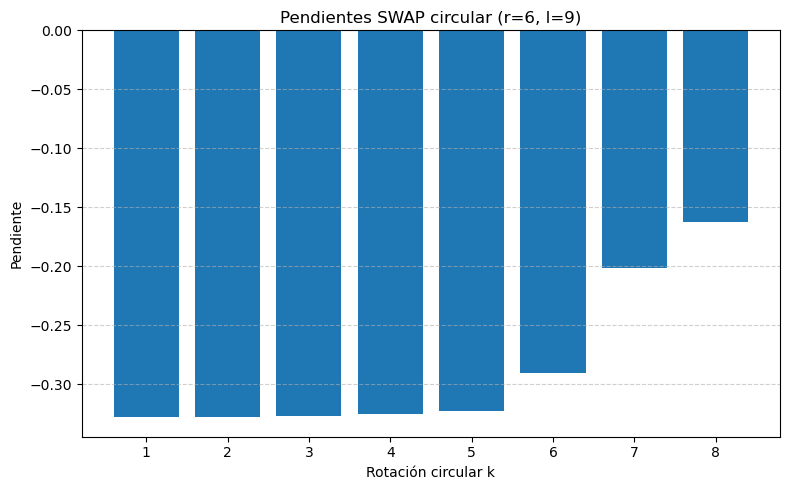

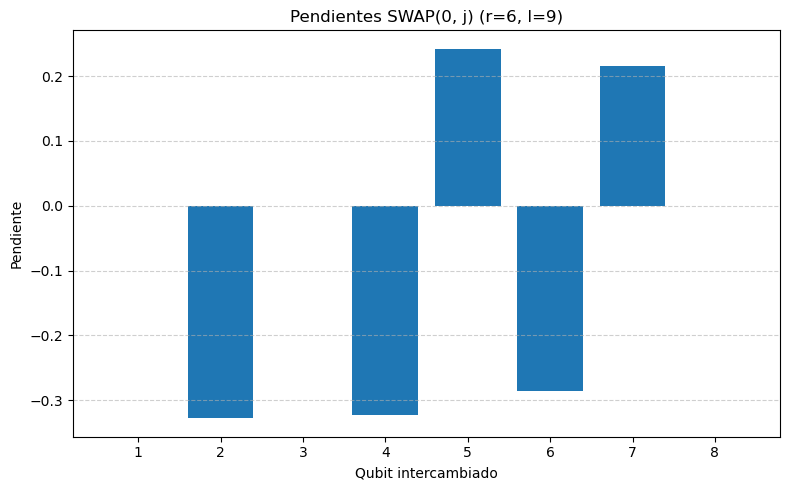

In [ ]:
r=6
l=9


graficar_pendientes_swaps_circulares(r, l)

graficar_pendientes_swap_fijo(r, l, qubit_fijo=0)


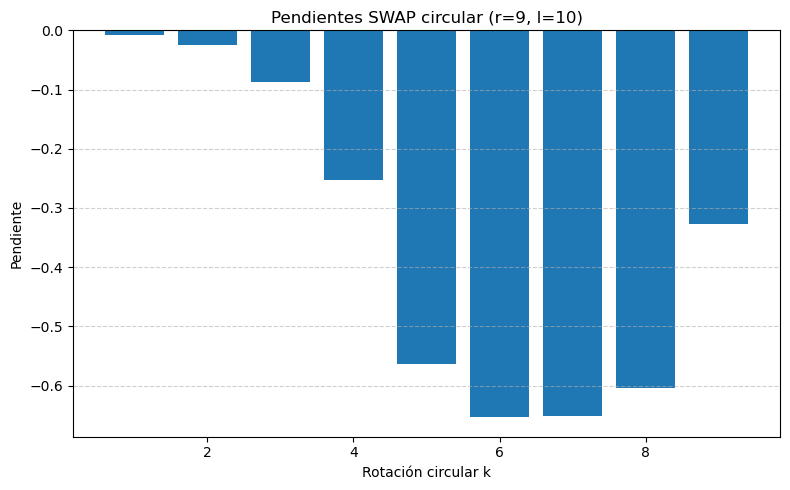

In [48]:
r=9
l=10


graficar_pendientes_swaps_circulares(r, l)


SWAPS circulares parecen distribuciones de Poisson??????? 


Quiero que veamos algo, comparemos la probabilidad de éxito de los algoritmos para valores de r concretos, identifique un patrón

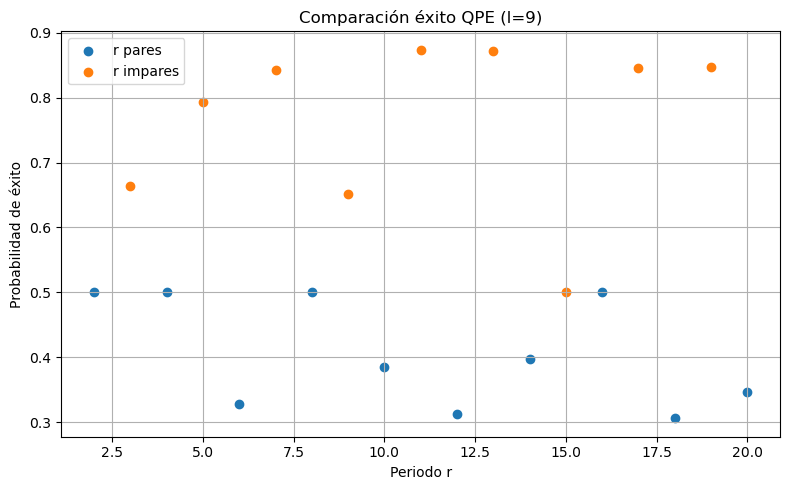

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Registro fijo
l = 9

# Rango de r a analizar
r_vals = range(2, 21)

r_pares = []
r_impares = []

probs_pares = []
probs_impares = []

for r in r_vals:
    prob = probabilidad_exito_QPE(r, l)
    
    if r % 2 == 0:
        r_pares.append(r)
        probs_pares.append(prob)
    else:
        r_impares.append(r)
        probs_impares.append(prob)

plt.figure(figsize=(8,5))

plt.scatter(r_pares, probs_pares, label="r pares")
plt.scatter(r_impares, probs_impares, label="r impares")

plt.xlabel("Periodo r")
plt.ylabel("Probabilidad de éxito")
plt.title(f"Comparación éxito QPE (l={l})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Exacto, los pares estan abajo del 0.5 y los impares arriba del 0.5, Hay una explicación matemática para esto. Para eso regresemos a esta definición:

Se denominan valores de éxito a aquellos resultados de la medición $y$ en el registro ancilla del order finding tales que la aproximación

$\frac{y}{2^n} \approx \frac{s}{r}$

es lo suficientemente precisa para que el algoritmo de fracciones continuas recupere la fracción $\frac{s}{r}$ con su denominador irreducible igual a 
$r$. En particular, los valores de éxito satisfacen

$\left| \frac{y}{2^n} - \frac{s}{r} \right| < \frac{1}{2r^2}.$

Además, un valor $y$ deja de ser de éxito si la fracción obtenida mediante fracciones continuas es reducible, es decir, si existe un divisor 
$d>1$ tal que

$\frac{s}{r} = \frac{s/d}{r/d}.$

En tal caso, el denominador obtenido no corresponde al orden real buscado.

La clave es el punto "un valor y deja de ser de éxito si la fracción obtenida mediante fracciones continuas es reducible". Y aqui pasa algo super curioso, si r es par, entonces la mitad de los valores de s (todo s par) acaba precisamente afectando al sistema. Aquí es donde conviene entender algo clave de la rutina de order finding. Es el algoritmo de QPE, de modo que va a tener picos asociados a s/r en su valor de probabilidad. Los picos utiles son los asociados a un s/r irreducible, donde s y r con coprimos, y los picos inútiles son los asociados a un s/r reducible

Ahora, en el caso de r par, si tu tomas el valor asociado a un pico, es probable que ese valor sea de un pico inútil, que se pueda mover a un pico util



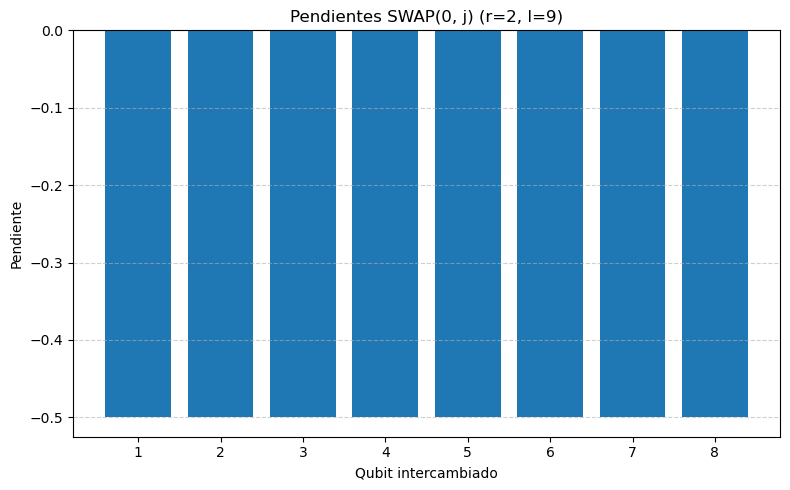

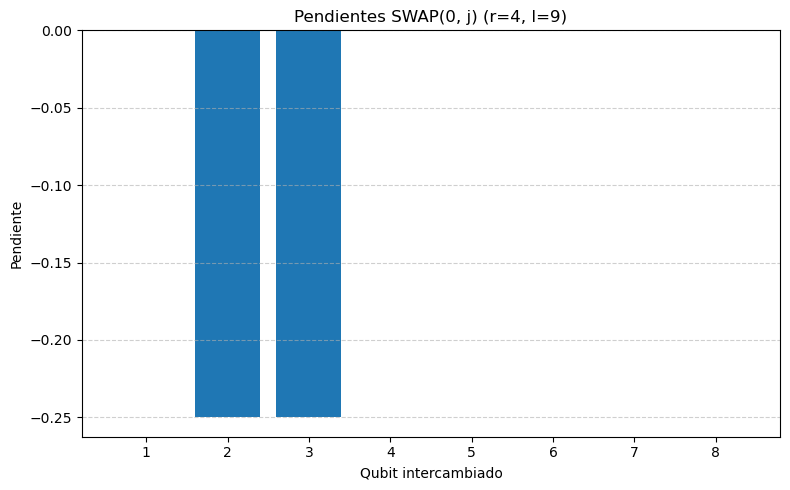

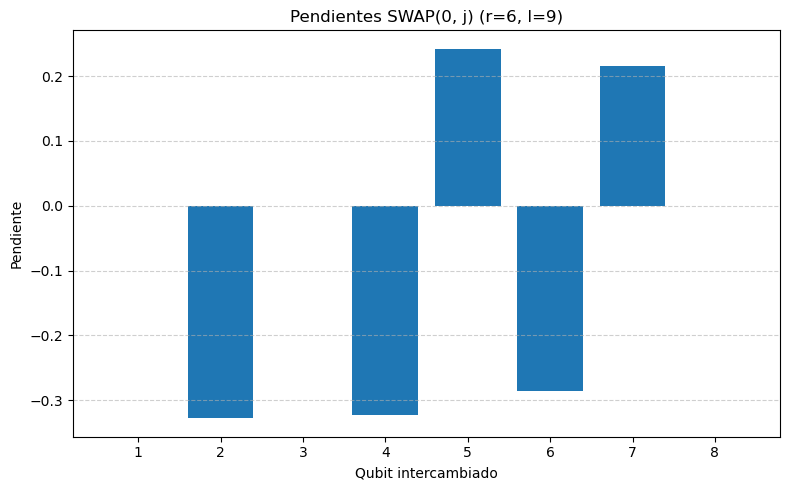

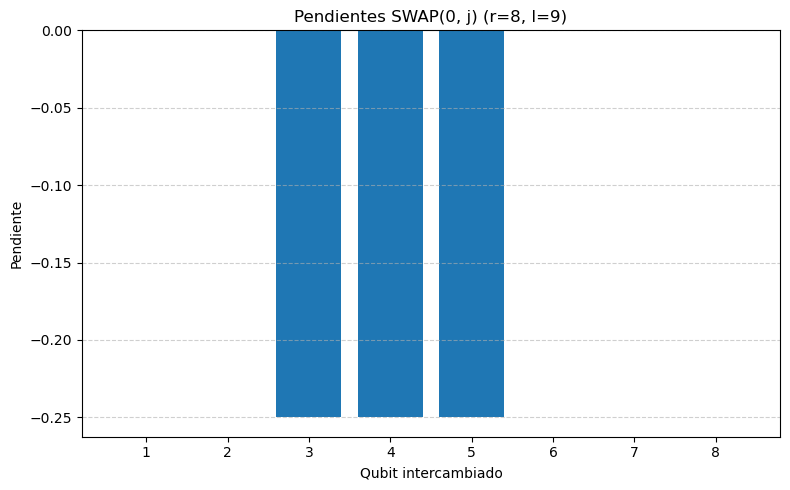

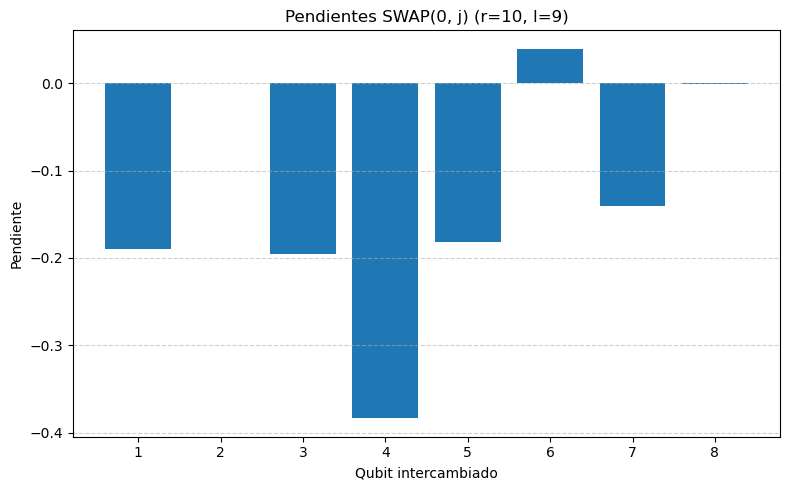

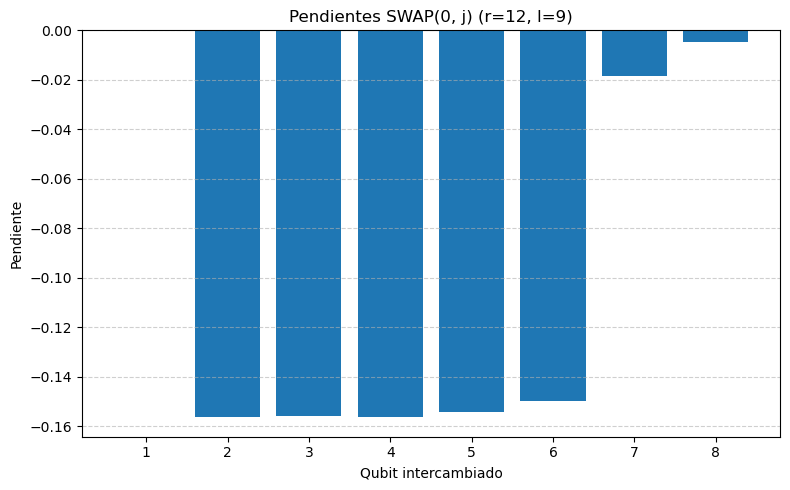

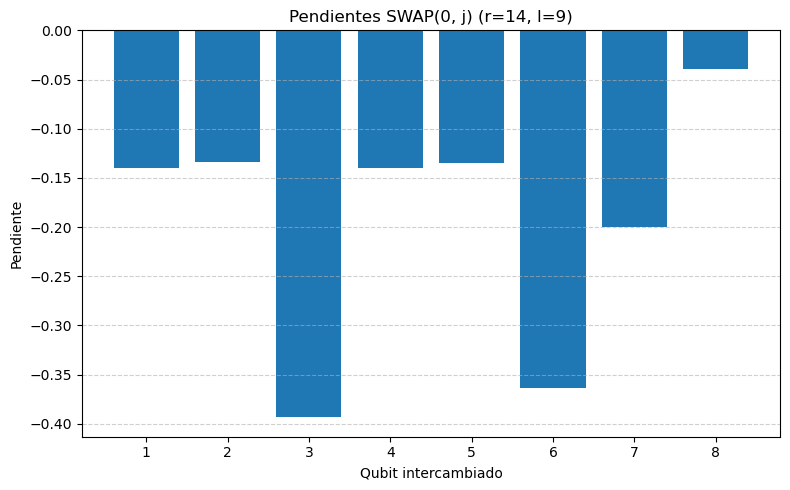

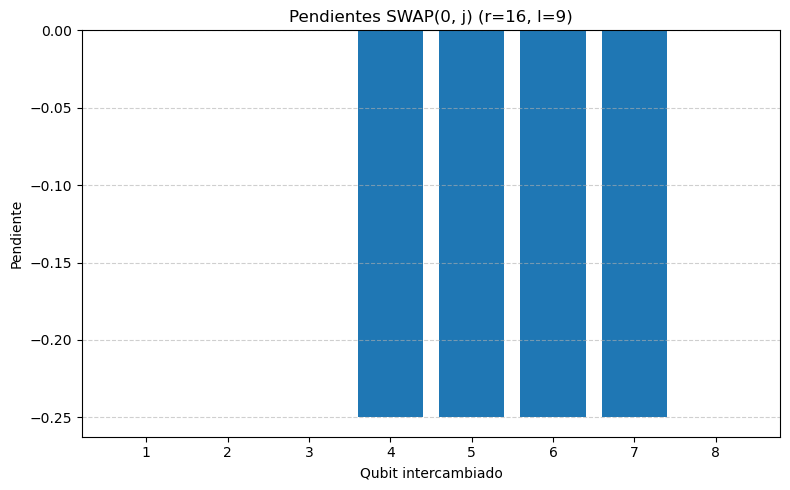

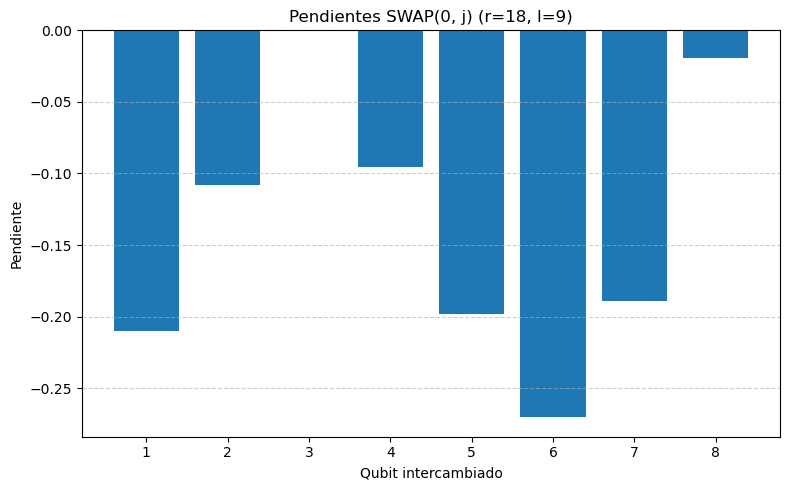

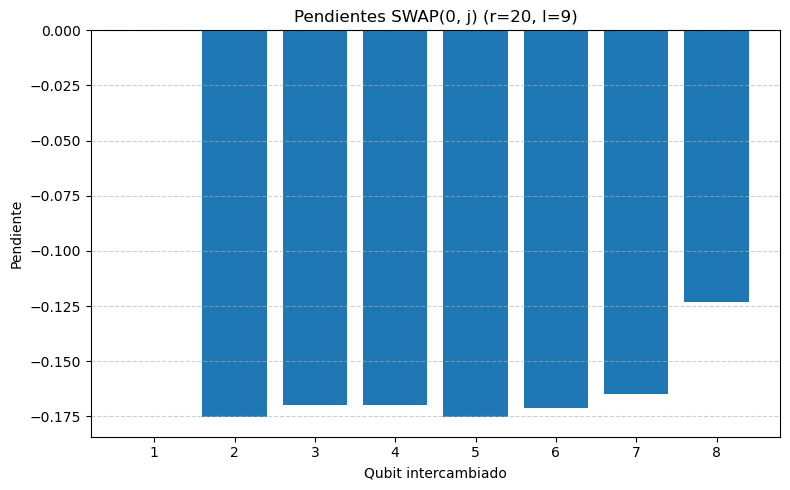

In [53]:

l = 9

for r in range(2, 21, 2):   # valores pares desde 2 hasta 20
    graficar_pendientes_swap_fijo(r, l, qubit_fijo=0)


Revisar los interceptos entre las gráficas